# EdgeSense: Real-Time Edge AI Optimization Pipeline

This notebook demonstrates an end-to-end Machine Learning optimization pipeline designed for edge devices.
Instead of relying on heavy cloud infrastructure, we take a standard vision model, fine-tune it for a specific use case (Driver Drowsiness Detection), and compress it using **INT8 Post-Training Quantization**.

**Pipeline Steps:**
1. Data Fetching & Preparation
2. Transfer Learning (Customizing MobileNetV2)
3. INT8 Quantization (Optimizing for Edge/Hardware)
4. Automated Benchmarking (Measuring Latency, FPS, and Memory)
5. Inference Test

In [8]:
# Upload kaggle.json to authenticate and download the dataset
from google.colab import files
import os

if not os.path.exists('kaggle.json'):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

# Setup Kaggle API and download the dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading and extracting dataset...")
!kaggle datasets download -d yasharjebraeily/drowsy-detection-dataset
!unzip -q drowsy-detection-dataset.zip -d dataset/
print("Dataset is ready!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/yasharjebraeily/drowsy-detection-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
  0% 0.00/14.2M [00:00<?, ?B/s]
100% 14.2M/14.2M [00:00<00:00, 1.41GB/s]
Dataset is ready!


## Step 1: Transfer Learning (Building the Base Model)
We start with a pre-trained **MobileNetV2**, an architecture already designed for mobile vision. We freeze its base layers and attach a custom classification head to train it specifically on our drowsiness dataset.

*Engineering Note:* The preprocessing function (`preprocess_input`) is embedded directly into the model graph via a Lambda layer to simplify deployment pipelines later.

In [9]:
import tensorflow as tf

DATASET_PATH = 'dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading dataset...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

# Building the Pipeline
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

# Save the original heavy model (FP32)
model.save('custom_drowsiness_model_fp32.h5')
print("FP32 Model saved.")

Loading dataset...
Found 7342 files belonging to 1 classes.
Using 5874 files for training.
Found 7342 files belonging to 1 classes.
Using 1468 files for validation.
Classes: ['Drowsy_datset']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


184/184 ━━━━━━━━━━━━━━━━━━━━ 54s 189ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


FP32 Model saved.


## Step 2: INT8 Post-Training Quantization
This is the core optimization step. We convert the heavy Float32 model into an INT8 TensorFlow Lite format.
To ensure we don't lose significant accuracy during this aggressive compression, we use a `representative_dataset` generator to calibrate the dynamic ranges (min/max) of all floating-point tensors.

In [10]:
import numpy as np

# Load the trained model with the custom lambda layer
custom_model = tf.keras.models.load_model(
    'custom_drowsiness_model_fp32.h5',
    custom_objects={'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input}
)

# Prepare a small dataset for calibration
rep_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, image_size=IMG_SIZE, batch_size=1, shuffle=True, seed=42
)

def representative_data_gen():
    for images, labels in rep_ds.take(150):
        yield [images]

print("Converting model to INT8...")
converter = tf.lite.TFLiteConverter.from_keras_model(custom_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Enforce full INT8 quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

quantized_model_path = 'custom_drowsiness_model_quant_int8.tflite'
with open(quantized_model_path, 'wb') as f:
    f.write(tflite_quant_model)

print(f"Success! Model quantized and saved as {quantized_model_path}")

Found 7342 files belonging to 1 classes.
Converting model to INT8...
Saved artifact at '/tmp/tmp03qa1471'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139269689217040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689218960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689214160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689219728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689219536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689220304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689220880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689220112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139269689217616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13926968922164

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Success! Model quantized and saved as custom_drowsiness_model_quant_int8.tflite


## Step 3: Benchmarking (Visualizing the Impact)
To quantify the ROI of our optimization, we run an automated benchmark comparing the original FP32 model against the new INT8 model. We measure:
1. **Model Size (MB)** - crucial for embedded storage.
2. **Inference Latency (ms)** - critical for real-time safety systems.
3. **Frames Per Second (FPS)** - overall system throughput.

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


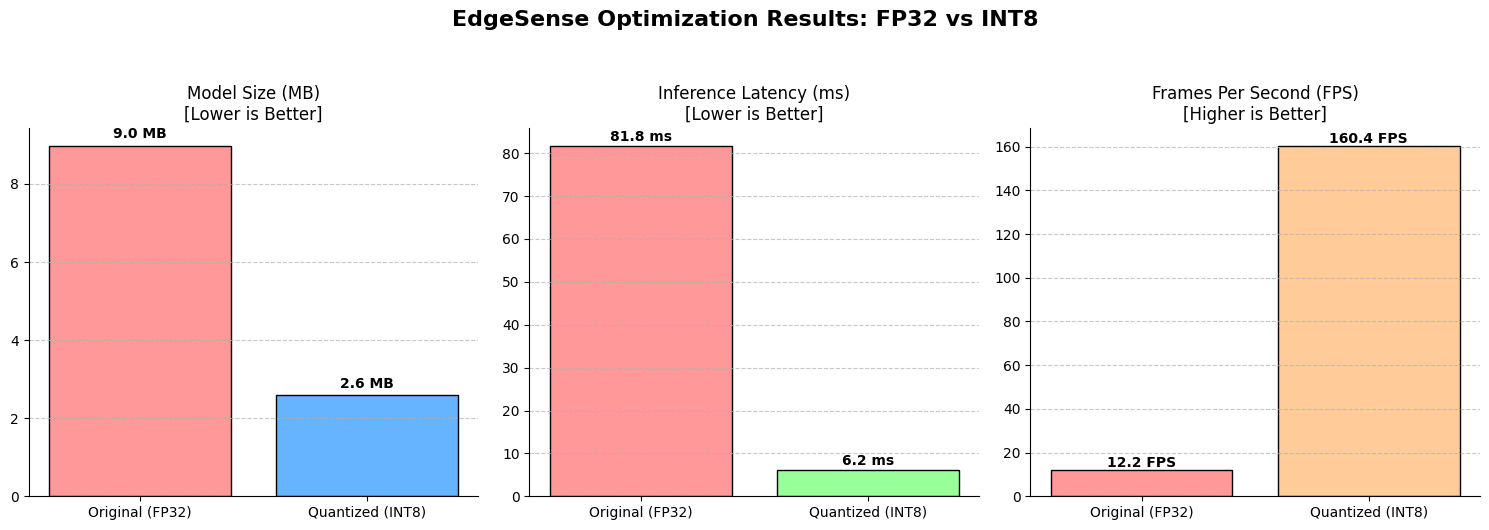

In [11]:
import os
import time
import matplotlib.pyplot as plt

fp32_path = 'custom_drowsiness_model_fp32.h5'
int8_path = 'custom_drowsiness_model_quant_int8.tflite'

fp32_size = os.path.getsize(fp32_path) / (1024 * 1024)
int8_size = os.path.getsize(int8_path) / (1024 * 1024)

# 1. Benchmark FP32
fp32_model = tf.keras.models.load_model(
    fp32_path, custom_objects={'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input}
)
dummy_input_fp32 = np.random.rand(1, 224, 224, 3).astype(np.float32)
_ = fp32_model.predict(dummy_input_fp32, verbose=0) # Warmup

start = time.time()
num_runs = 50
for _ in range(num_runs):
    _ = fp32_model.predict(dummy_input_fp32, verbose=0)
fp32_time = ((time.time() - start) / num_runs) * 1000
fp32_fps = 1000 / fp32_time

# 2. Benchmark INT8
interpreter = tf.lite.Interpreter(model_path=int8_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]
dummy_input_int8 = np.random.randint(-128, 127, size=input_details['shape'], dtype=np.int8)

interpreter.set_tensor(input_details['index'], dummy_input_int8)
interpreter.invoke() # Warmup

start = time.time()
for _ in range(num_runs):
    interpreter.set_tensor(input_details['index'], dummy_input_int8)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_details['index'])
int8_time = ((time.time() - start) / num_runs) * 1000
int8_fps = 1000 / int8_time

# 3. Plotting
labels = ['Original (FP32)', 'Quantized (INT8)']
sizes = [fp32_size, int8_size]
times = [fp32_time, int8_time]
fps_vals = [fp32_fps, int8_fps]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EdgeSense Optimization Results: FP32 vs INT8', fontsize=16, fontweight='bold', y=1.05)

axes[0].bar(labels, sizes, color=['#ff9999','#66b3ff'], edgecolor='black')
axes[0].set_title('Model Size (MB)\n[Lower is Better]')
for i, v in enumerate(sizes): axes[0].text(i, v + 0.2, f"{v:.1f} MB", ha='center', fontweight='bold')

axes[1].bar(labels, times, color=['#ff9999','#99ff99'], edgecolor='black')
axes[1].set_title('Inference Latency (ms)\n[Lower is Better]')
for i, v in enumerate(times): axes[1].text(i, v + 1, f"{v:.1f} ms", ha='center', fontweight='bold')

axes[2].bar(labels, fps_vals, color=['#ff9999','#ffcc99'], edgecolor='black')
axes[2].set_title('Frames Per Second (FPS)\n[Higher is Better]')
for i, v in enumerate(fps_vals): axes[2].text(i, v + 1, f"{v:.1f} FPS", ha='center', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Step 4: Edge Inference Testing
Finally, we test the compressed INT8 model. Since the model expects strict integer inputs, we must perform programmatic **quantization (scaling and zero-point shifting)** on the input image, and **de-quantization** on the output probabilities to get readable confidence scores.

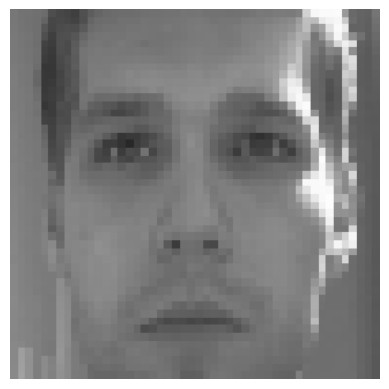

Predicted State: Drowsy_datset
Confidence: 99.61%


In [12]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Select a random test image
all_images = []
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

test_image_path = random.choice(all_images)
img = load_img(test_image_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')
plt.show()

# Standard Preprocessing
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Input Quantization (Float -> INT8)
input_scale, input_zero_point = input_details['quantization']
if input_scale > 0.0:
    img_array = img_array / input_scale + input_zero_point
    img_array = np.round(img_array).astype(np.int8)

# Inference
interpreter.set_tensor(input_details['index'], img_array)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details['index'])[0]

# Output De-quantization (INT8 -> Float)
output_scale, output_zero_point = output_details['quantization']
if output_scale > 0.0:
    output_data = (output_data.astype(np.float32) - output_zero_point) * output_scale

predicted_class_idx = np.argmax(output_data)
confidence = output_data[predicted_class_idx]
predicted_label = class_names[predicted_class_idx]

print(f"Predicted State: {predicted_label}")
print(f"Confidence: {confidence * 100:.2f}%")